In [17]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

Poisson equation $\nabla^2 p = b$

The p and b data in cell_center_data is the exact same as the p and b in the parent dataset except the boundaries are stripped.

In this dataset, we should use Homogeneous Dirichlet Boundary Condition ($p = 0$).

$b$ is the source, $p$ is the pressure simulation ground truth, $\eta$ (eta) represents the geometric boundary mask of the solid obstacles where 0 means fluid, 1.0 means boundary.

This dataset is a simplier version of a bigger stokes flow dataset because we remove $u$ and $v$, where $b = \frac{\rho}{\Delta t} \nabla \cdot \mathbf{u}^*$

We solve the pressure Poisson equation here to predict $p$, meaning we want to learn the mapping $(b, \eta) \rightarrow p$ in a single forward pass.
For the physics loss function, we do $\nabla^2 p_{pred} = b$. For evaluation, we compare $p_{pred}$ with the simulation $p_{sim}$. We can add both into the loss function actually.

In [ ]:
T = 10
n_short = 10
n_gap = 20

DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-solver" / "T10_data"

# 960x512
p_file = DATA_DIR / "cell_center_data" / "p" / f"dxdy_960x512_p_T{T}_S{n_short}_G{n_gap}.npy"
b_file = DATA_DIR / "cell_center_data" / "b" / f"dxdy_960x512_b_T{T}_S{n_short}_G{n_gap}.npy"

# 962x514
eta_file = DATA_DIR / "eta" / f"dxdy_960x512_eta_T{T}_S{n_short}_G{n_gap}.npy"
# p_file = DATA_DIR / "p" / f"dxdy_960x512_p_T{T}_S{n_short}_G{n_gap}.npy"
# b_file = DATA_DIR / "b" / f"dxdy_960x512_b_T{T}_S{n_short}_G{n_gap}.npy"


In [19]:
p_grid = np.load(p_file)
b_grid = np.load(b_file)
eta_grid = np.load(eta_file)

print(f"The shape of the raw p array is: {p_grid.shape}")
print(f"The shape of the raw b array is: {b_grid.shape}")
print(f"The shape of the raw eta array is: {eta_grid.shape}")

eta_grid = eta_grid[1:-1, 1:-1]
print(f"The shape of the raw eta array is: {eta_grid.shape}")

The shape of the raw p array is: (960, 512)
The shape of the raw b array is: (960, 512)
The shape of the raw eta array is: (962, 514)
The shape of the raw eta array is: (960, 512)


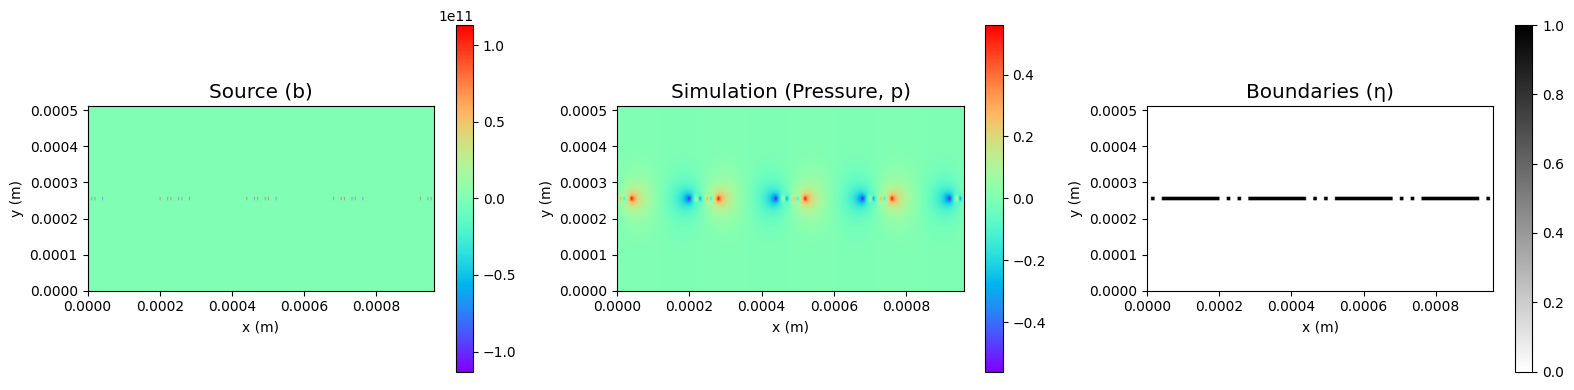

In [ ]:
# 1. Define the physical extents (from L = 1.0e-6)
L = 1.0e-6
l_x = L * 960
l_y = L * 512
ext = [0, l_x, 0, l_y]

fig = plt.figure(figsize=(16, 4)) # Made it a bit wider to fit 3 plots

ax1 = fig.add_subplot(1, 3, 1)
s_plot = b_grid.T
mesh1 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Source (b)', fontsize='x-large')

ax2 = fig.add_subplot(1, 3, 2)
s_plot = p_grid.T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Simulation (Pressure, p)', fontsize='x-large')

ax3 = fig.add_subplot(1, 3, 3)
s_plot = eta_grid.T
mesh3 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='binary', extent=ext, aspect=1.)
plt.colorbar(mesh3)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Boundaries (\u03B7)', fontsize='x-large')

plt.tight_layout()
plt.show()

Loaded p shape: (960, 512)
Loaded b shape: (960, 512)


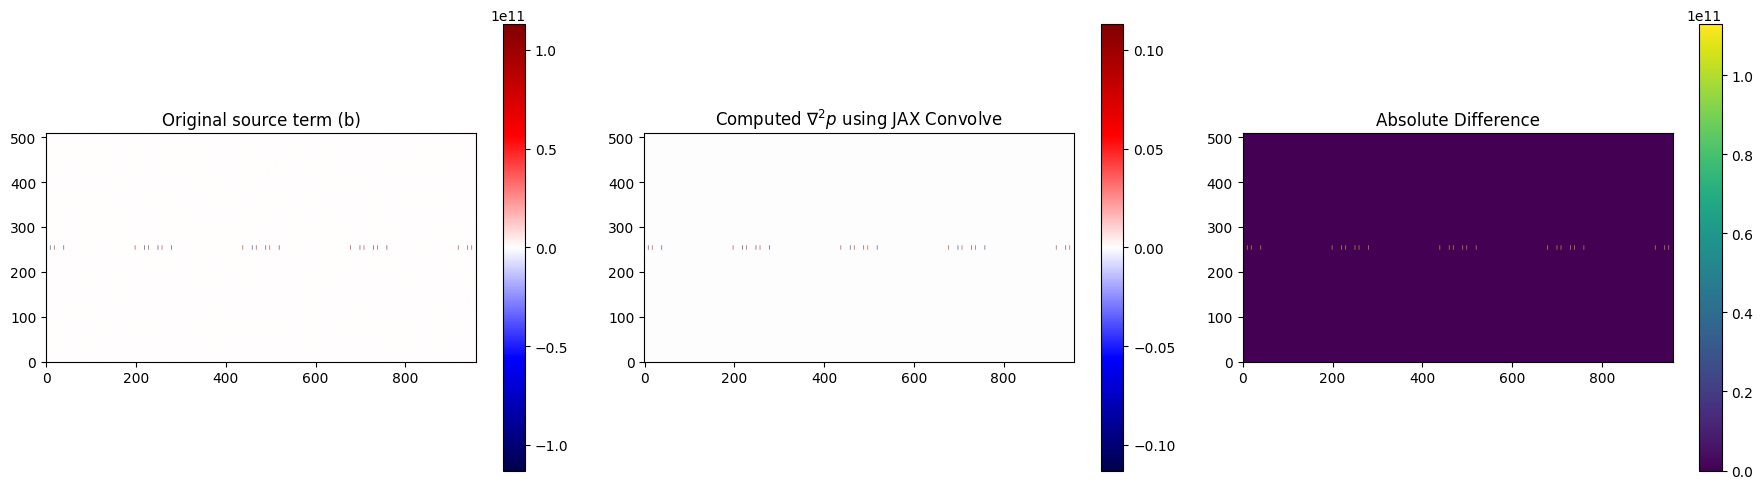

In [21]:
import jax
import jax.numpy as jnp
from jax.scipy.signal import convolve2d
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Setup paths (Adjust as needed)
T = 10
S = 10
G = 20
DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-solver" / "T10_data"

# We use the cell_center_data so we don't have to deal with ghost cell boundaries manually
p_file = DATA_DIR / "cell_center_data" / "p" / f"dxdy_960x512_p_T{T}_S{S}_G{G}.npy"
b_file = DATA_DIR / "cell_center_data" / "b" / f"dxdy_960x512_b_T{T}_S{S}_G{G}.npy"

# Load data into JAX arrays
p_grid = jnp.array(np.load(p_file))
b_grid = jnp.array(np.load(b_file))

print(f"Loaded p shape: {p_grid.shape}")
print(f"Loaded b shape: {b_grid.shape}")

# 2. Define the finite difference Laplacian kernel
# del^2 p = (p_{i+1,j} + p_{i-1,j} + p_{i,j+1} + p_{i,j-1} - 4*p_{i,j}) / (dx^2)
# Note: For a quick correlation check, we omit dx^2 to look at the unscaled structure.
laplacian_kernel = jnp.array([
    [0.0,  1.0, 0.0],
    [1.0, -4.0, 1.0],
    [0.0,  1.0, 0.0]
])

# 3. Apply the Convolution using JAX
# 'valid' drops the boundary edges where the kernel goes out of bounds
laplacian_p = convolve2d(p_grid, laplacian_kernel, mode='valid')

# Slice b_grid to match the 'valid' convolution shape (dropping 1 cell on all sides)
b_grid_sliced = b_grid[1:-1, 1:-1]

# 4. Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot B (The True Source)
im0 = axes[0].imshow(b_grid_sliced.T, cmap='seismic', origin='lower')
axes[0].set_title('Original source term (b)', fontsize=12)
fig.colorbar(im0, ax=axes[0])

# Plot Laplacian of P (Our reconstructed Source)
im1 = axes[1].imshow(laplacian_p.T, cmap='seismic', origin='lower')
axes[1].set_title('Computed $\\nabla^2 p$ using JAX Convolve', fontsize=12)
fig.colorbar(im1, ax=axes[1])

# Plot the Absolute Error
error = jnp.abs(laplacian_p - b_grid_sliced)
im2 = axes[2].imshow(error.T, cmap='viridis', origin='lower')
axes[2].set_title('Absolute Difference', fontsize=12)
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from pathlib import Path

# Setup paths (Using your T10, S10, G20 example)
T, S, G = 10, 10, 20
DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-solver" / "T10_data"

# 1. Load the data
# Main folder data (Expected: 962x514)
p_main = np.load(DATA_DIR / "p" / f"dxdy_960x512_p_T{T}_S{S}_G{G}.npy")
b_main = np.load(DATA_DIR / "b" / f"dxdy_960x512_b_T{T}_S{S}_G{G}.npy")

# Cell Center data (Expected: 960x512)
p_center = np.load(DATA_DIR / "cell_center_data" / "p" / f"dxdy_960x512_p_T{T}_S{S}_G{G}.npy")
b_center = np.load(DATA_DIR / "cell_center_data" / "b" / f"dxdy_960x512_b_T{T}_S{S}_G{G}.npy")

print(f"Main P shape: {p_main.shape} | Center P shape: {p_center.shape}")

# 2. Check Equivalence
# Slice the 1-cell thick boundary off the main arrays
p_main_sliced = p_main[1:-1, 1:-1]
b_main_sliced = b_main[1:-1, 1:-1]

# We use np.allclose to account for potential tiny floating-point precision differences
p_match = np.allclose(p_main_sliced, p_center)
b_match = np.allclose(b_main_sliced, b_center)

print(f"\nDo the inner P arrays match exactly? {p_match}")
print(f"Do the inner B arrays match exactly? {b_match}")

# 3. Inspect the Boundaries (Ghost Cells vs Inner Cells)
# Let's look at the bottom edge (y=0) to see what boundary condition is applied
print("\n--- Inspecting P Boundaries (Bottom Edge) ---")
print(f"Bottom Ghost Cell row (first 5 elements): {p_main[0, 1:6]}")
print(f"Bottom Inner Cell row (first 5 elements): {p_main[1, 1:6]}")

# Let's look at the right edge (x=L) 
print("\n--- Inspecting P Boundaries (Right Edge) ---")
print(f"Right Ghost Cell col (first 5 elements): {p_main[1:6, -1]}")
print(f"Right Inner Cell col (first 5 elements): {p_main[1:6, -2]}")

print("\nBased on the above data, we should use Homogeneous Dirichlet Boundary Condition ($p = 0$)")

Main P shape: (962, 514) | Center P shape: (960, 512)

Do the inner P arrays match exactly? True
Do the inner B arrays match exactly? True

--- Inspecting P Boundaries (Bottom Edge) ---
Bottom Ghost Cell row (first 5 elements): [-8.32398502e-08 -3.15720828e-07 -4.82478023e-07 -7.15504383e-07
 -8.83094836e-07]
Bottom Inner Cell row (first 5 elements): [8.32398502e-08 3.15720828e-07 4.82478023e-07 7.15504383e-07
 8.83094836e-07]

--- Inspecting P Boundaries (Right Edge) ---
Right Ghost Cell col (first 5 elements): [-8.32398502e-08 -3.15583942e-07 -4.81788694e-07 -7.13583082e-07
 -8.78963760e-07]
Right Inner Cell col (first 5 elements): [8.32398502e-08 3.15583942e-07 4.81788694e-07 7.13583082e-07
 8.78963760e-07]

Based on the above data, we should use Homogeneous Dirichlet Boundary Condition ($p = 0$)


1. Unique values in eta grid: [0. 1.]
   -> Conclusion: Eta is a binary mask (e.g., 0 for fluid, 1 for solid).

2. The sifter is actually located at Y-index (row): 251

3. Visualizing the first 100 micrometers (cells) of the sifter:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


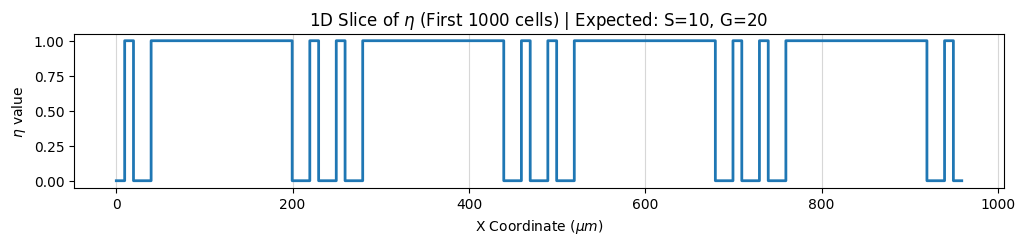

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths (Adjust to match your current test case)
T, S, G = 10, 10, 20
DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-solver" / "T10_data"
eta_file = DATA_DIR / "eta" / f"dxdy_960x512_eta_T{T}_S{S}_G{G}.npy"

# Load the eta array
eta_grid = np.load(eta_file)

# 1. Check what values make up the mask
unique_vals = np.unique(eta_grid)
print(f"1. Unique values in eta grid: {unique_vals}")
if len(unique_vals) <= 2:
    print("   -> Conclusion: Eta is a binary mask (e.g., 0 for fluid, 1 for solid).")

# 2. Strip the ghost cells to match the physical 960x512 domain
eta_inner = eta_grid[1:-1, 1:-1]

# 3. Find exactly where the sifter is located on the Y-axis
# We sum across the X-axis. Rows with fluid will sum to 0. The row with the sifter will have a high sum.
col_sums = np.sum(eta_inner, axis=0) 
sifter_y_index = np.argmax(col_sums)
print(f"\n2. The sifter is actually located at Y-index (row): {sifter_y_index}")

# 4. Extract a 1D horizontal slice right through the sifter
# We fix the Y-index and pull all X-values
sifter_slice = eta_inner[:, sifter_y_index]

# 5. Print a chunk of the slice to visually verify S and G
print(f"\n3. Visualizing the first 100 micrometers (cells) of the sifter:")
print(sifter_slice[:100])

# Plot the 1D slice
plt.figure(figsize=(12, 2))
plt.plot(sifter_slice[:1000], drawstyle='steps-mid', linewidth=2)
plt.title(rf"1D Slice of $\eta$ (First 1000 cells) | Expected: S={S}, G={G}")
plt.xlabel(r"X Coordinate ($\mu m$)")
plt.ylabel(r"$\eta$ value")
plt.grid(True, axis='x', alpha=0.5)
plt.show()